# Optimization results

**One-paragraph version.** This project turns raw brain-recording voltage into spikes and spike-band power, one millisecond at a time, for up to 2048 electrodes. Real time means finishing each second of data in under one second of clock time. Three changes made the code faster without changing any output: re-referencing each group of electrodes with a small matrix built once, running the backward half of the filter as one multiply, and compiling the forward half of the filter so eight electrodes update in one CPU instruction. On a 4-core Xeon, 1024 electrodes now run in real time. 2048 do not yet. Four other ideas were tried, measured, and removed because they made things slower; the table near the end says by how much and why.

**How to read this notebook.** Each section states what is measured, how, and in what units, then prints the numbers. Markdown cells explain; code cells measure. Every number is from the run saved in this file, on the computer named in the first output. The two tables that matter most are **"Results at a glance"** and **"Attempts that did not help"**, both near the end.

**Recordings used.**

- **Real recording** `data/NSP1_aligned.ns6`: 128 electrodes from a Utah-array implant, 30 kHz, about 96 seconds. Thresholds and linear-regression re-reference weights come from `calc_params.py` on its first 60 seconds (`-t -3.5 --reref lrr -d 60`). The first 10 seconds are run through both paths. Download it with `scripts/fetch_example_data.sh`; this notebook says so and skips that section if the file is missing.
- **Synthetic recording** built in memory: groups of 64 electrodes, Gaussian noise, and a short negative pulse every 10 ms. The real file has 128 electrodes, so the 1024- and 2048-electrode rows use this, and one table also tiles the real electrodes to those sizes.

**What "matches" means.** The fast code is compared with the original loop on the same samples. A difference of 0 means the same spikes, the same filtered voltage, and the same spike-band power, bit for bit.


## Glossary

- **Electrode / channel.** One recording site. Used interchangeably here.
- **30 kHz.** 30,000 voltage samples per second per electrode, so 30 samples per millisecond.
- **Window.** One millisecond of data: 30 samples for every electrode.
- **ms wall per second of data.** The unit for every timing. How many milliseconds the computer needed to process one second of recording. Under 1000 is real time. Lower is better.
- **Steady state.** The processor is already built and warmed up. This is what a live session looks like after the first millisecond, and it is the real-time number.
- **Setup included.** The timer also covers designing the filter and building the processor. That happens once per session, so this is not the real-time number. It is kept because that is how the first comparison was measured.
- **The five stages.** *Re-reference* subtracts shared noise. *Forward filter* keeps 250-5000 Hz, running forward in time. *Reverse filter* runs the same filter backward over a 4 ms look-ahead so spikes are not shifted in time. *Features* checks each electrode for a threshold crossing and averages the log power. *Write* copies the millisecond into the output arrays.
- **Lossless.** Same output as the original loop. **Lossy.** Output changes (only the 15 kHz option).
- **AVX-512.** A set of CPU instructions on recent Intel and some AMD chips that operate on eight 64-bit numbers at once.
- **BLAS / the multiply.** The math library that does matrix multiplication. The reverse filter and the re-reference use it.


In [1]:
%matplotlib inline
import contextlib
import io
import os
import platform
import time
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import numpy as np

from optimizations import (
    AntiAliasDecimator,
    OptimizedProcessor,
    _apply_fir,
    select_gpu_device,
)
from utils import build_filter, rereference_data

SAMPLE_RATE = 30_000
SAMPLES_PER_MS = 30
GROUP_SIZE = 64

NOTEBOOK_T0 = time.perf_counter()
SECTION_TIMES = []


class Section:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc, tb):
        SECTION_TIMES.append((self.name, time.perf_counter() - self.t0))
        return False


def cpu_label():
    text = ""
    try:
        text = open("/proc/cpuinfo", encoding="utf-8").read()
    except OSError:
        text = ""
    model = "unknown CPU"
    for line in text.splitlines():
        if line.startswith("model name"):
            model = line.split(":", 1)[1].strip()
            break
    avx = "AVX-512" if "avx512f" in text else "no AVX-512"
    guest = "KVM guest" if "hypervisor" in text else "bare metal"
    return f"{model}, {os.cpu_count()} cores, {avx}, {guest}, {platform.machine()}"


print(cpu_label())


Intel(R) Xeon(R) Processor, 4 cores, AVX-512, KVM guest, x86_64


## Synthetic recording

Each group of 64 electrodes is one array. They share a common average: the mean of the group is subtracted from each electrode. Every 10 ms, one electrode gets a short negative pulse, which is what the threshold is meant to catch. Everything else is Gaussian noise with a fixed seed, so the test is repeatable. The real recording section uses measured thresholds and fitted weights instead.

`quiet` hides the "Loading filter" line that the original code prints each time it builds a filter.


In [2]:
def make_recording(n_channels, n_ms, seed=0, spike_every_ms=10, spike_amp=-500.0):
    rng = np.random.default_rng(seed)
    n_samples = n_ms * SAMPLES_PER_MS
    raw = rng.normal(scale=20.0, size=(n_channels, n_samples))
    groups = [
        list(range(start, min(start + GROUP_SIZE, n_channels)))
        for start in range(0, n_channels, GROUP_SIZE)
    ]
    reref_params = np.zeros((n_channels, n_channels))
    for group in groups:
        reref_params[np.ix_(group, group)] = 1.0 / len(group)
    for ms in range(8, n_ms, spike_every_ms):
        channel = (ms // spike_every_ms) % n_channels
        start = ms * SAMPLES_PER_MS + 12
        raw[channel, start:start + 2] = spike_amp
    thresholds = np.full((n_channels, 1), -120.0)
    return raw, reref_params, thresholds, groups


def quiet(fn):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn()


## Before: the original loop

This is the loop from `baseline.ipynb`, unchanged. For every millisecond it:

1. rebuilds the full electrode-by-electrode re-reference matrix and multiplies,
2. runs the forward filter with SciPy,
3. runs the backward filter as a Python loop, one electrode at a time,
4. checks for threshold crossings and averages the log power.

Steps 1 and 3 are the expensive ones, and they are what the first two optimizations replace.


In [3]:
def run_baseline(raw, reref_params, thresholds):
    n_channels = raw.shape[0]
    n_windows = raw.shape[1] // SAMPLES_PER_MS
    lag = int(round(0.004 * SAMPLE_RATE))
    filter_func, sos, zi, rev_win, rev_zi = build_filter(
        n_channels=n_channels,
        but_low=250,
        but_high=5000,
        causal=False,
        acausal_filter_type="fir",
        acausal_filter_lag=lag,
        fs=SAMPLE_RATE,
    )
    spikes = np.zeros((n_channels, n_windows), dtype=np.int16)
    spike_band = np.zeros((n_channels, n_windows), dtype=np.float32)
    filtered = np.zeros((n_channels, n_windows * SAMPLES_PER_MS), dtype=np.float32)
    rev_buffer = np.full((n_channels, lag + SAMPLES_PER_MS), np.nan, dtype=np.float32)
    filt_buffer = np.zeros((n_channels, SAMPLES_PER_MS), dtype=np.float32)
    thresholds = np.asarray(thresholds).reshape(-1, 1)
    for index in range(n_windows):
        start = index * SAMPLES_PER_MS
        stop = start + SAMPLES_PER_MS
        reref = rereference_data(raw[:, start:stop], reref_params)
        filter_func(reref, filt_buffer, rev_buffer, sos, zi, rev_win, rev_zi)
        filtered[:, start:stop] = filt_buffer
        crossings = (
            (filt_buffer[:, 1:] < thresholds) & (filt_buffer[:, :-1] >= thresholds)
        )
        spikes[:, index] = np.any(crossings, axis=1).astype(np.int16)
        spike_band[:, index] = (10 * np.log10(np.square(filt_buffer))).mean(axis=1)
    return filtered, spikes, spike_band


with Section("before: baseline loop"):
    N_CHANNELS = 128
    N_MS = 200
    raw, reref_params, thresholds, groups = make_recording(N_CHANNELS, N_MS)
    before_filtered, before_spikes, before_sbp = quiet(
        lambda: run_baseline(raw, reref_params, thresholds)
    )
print(f"before: {before_spikes.shape[0]} channels, {before_spikes.shape[1]} ms, {int(before_spikes.sum())} spikes")


before: 128 channels, 200 ms, 19 spikes


## After: the fast processor

Same recording, same thresholds, same weights. `OptimizedProcessor` does the same four steps with:

- one small re-reference matrix per group of 64 electrodes, built once;
- the forward filter compiled for AVX-512 when the CPU has it (the output below says which);
- the backward filter as one multiply across all electrodes;
- spikes returned three ways: full grid, `(electrode, millisecond)` list, compressed matrix.

`per_array_threads` and `per_channel_threads` are accepted for old callers and do not start threads. The reason is in the attempts table.


In [4]:
def run_optimized(raw, reref_params, thresholds, groups, **kwargs):
    defaults = dict(
        per_array_threads=True,
        per_channel_threads=True,
        use_gpu=False,
        decimate=False,
    )
    defaults.update(kwargs)
    with OptimizedProcessor(
        n_channels=raw.shape[0],
        reref_params=reref_params,
        thresholds=thresholds,
        reref_groups=groups,
        sample_rate=SAMPLE_RATE,
        **defaults,
    ) as processor:
        return processor, processor.process_recording(raw)


with Section("after: optimized recording"):
    processor, after = quiet(lambda: run_optimized(raw, reref_params, thresholds, groups))
print(f"after:  {after.spikes.shape[0]} channels, {after.spikes.shape[1]} ms, {int(after.spikes.sum())} spikes")
print(f"events: {after.spike_events.shape[0]}")
print(f"forward filter: {processor.forward_impl}")


after:  128 channels, 200 ms, 19 spikes
events: 19
forward filter: avx512


## Agreement on the synthetic recording

Lossless means the filtered waveform, the spike grid, and the spike-band power match the original loop. The first 4 ms are NaN on both paths while the look-ahead buffer fills, and those NaNs are counted as equal. All three differences should print as 0.


In [5]:
with Section("agreement"):
    filtered_diff = np.nanmax(np.abs(after.filtered - before_filtered))
    sbp_diff = np.nanmax(np.abs(after.spike_band_power - before_sbp))
    spike_mismatches = int(np.sum(after.spikes != before_spikes))
print(f"max |filtered difference|:     {filtered_diff:.3e}")
print(f"max |spike-band difference|:   {sbp_diff:.3e}")
print(f"spike bin mismatches:          {spike_mismatches} of {before_spikes.size}")
print(f"spikes before / after:         {int(before_spikes.sum())} / {int(after.spikes.sum())}")


max |filtered difference|:     0.000e+00
max |spike-band difference|:   0.000e+00
spike bin mismatches:          0 of 25600
spikes before / after:         19 / 19


## Agreement on the real recording

`NSP1_aligned.ns6` is a Blackrock file: 128 electrodes, 30 kHz, int16 voltages. The thresholds are −3.5 times each electrode's RMS after filtering, and the re-reference is a linear regression fit inside each 64-electrode group, both from `calc_params.py` on the first 60 seconds. The first 10 seconds go through the original loop and the fast processor with the same raw samples, weights, and thresholds.

This is the check that the optimizations hold on real data, with realistic spike shapes, per-electrode thresholds, and fitted weights. If the file or its JSON is missing, this cell prints how to get them and the rest of the notebook still runs.



NSP1_aligned.ns6 closed
file: 128 electrodes, 96.4 s at 30000 Hz, dtype int16
groups: 2 x 64 electrodes, linear-regression weights
thresholds: -207.5 to -20.1 (−3.5 x RMS)


forward filter: avx512
max |filtered difference|:   0.000e+00
max |spike-band difference|: 0.000e+00
spike bin mismatches:        0 of 1280000
spikes before / after:       26611 / 26611
spikes per second per electrode: median 13.8, max 79.5


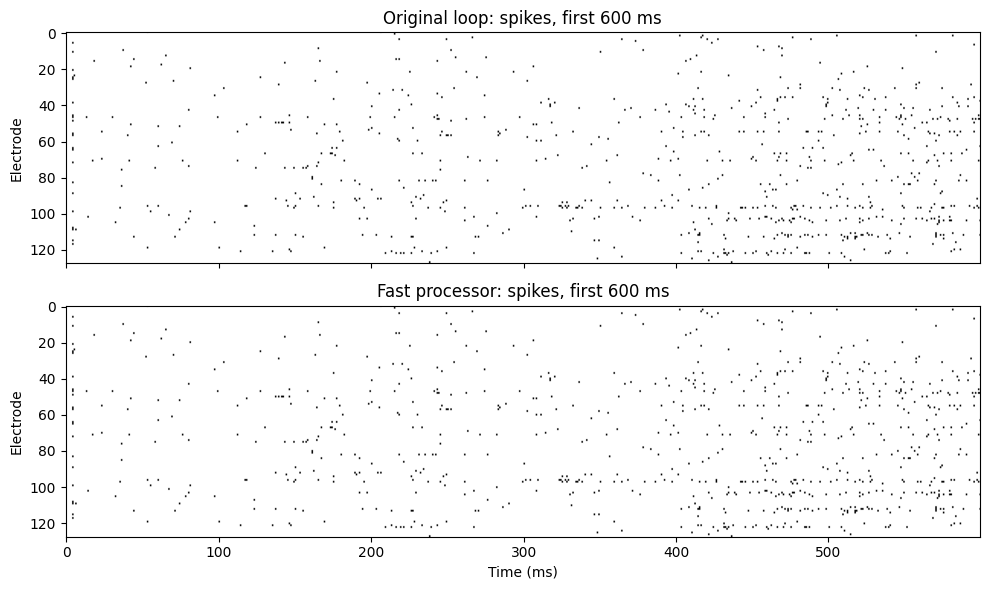

In [6]:
import json
import os

REAL_NS6 = "../data/NSP1_aligned.ns6"
REAL_PARAMS = "../data/NSP1_aligned_params.json"
REAL_SECONDS = 10
real = None

if not (os.path.exists(REAL_NS6) and os.path.exists(REAL_PARAMS)):
    print("Real recording not found.")
    print("  ./scripts/fetch_example_data.sh")
    print("  cd notebooks && python calc_params.py -f ../data/NSP1_aligned.ns6 "
          "-o ../data/NSP1_aligned_params.json -t -3.5 --reref lrr -d 60")
else:
    import brpylib

    with Section("real recording: load"):
        file_params = json.load(open(REAL_PARAMS))
        real_reref = np.array(file_params["rereference_parameters"])
        real_thr = np.array(file_params["thresholds"]).reshape(-1, 1)
        real_groups = [list(g) for g in file_params["reref_groups"]]
        nsx = brpylib.NsxFile(REAL_NS6)
        real_raw_all = nsx.getdata()["data"][0]
        nsx.close()
        real_rate = float(file_params["sample_rate"])
        real_raw = real_raw_all[:, :REAL_SECONDS * int(real_rate)]
    print(f"file: {real_raw_all.shape[0]} electrodes, {real_raw_all.shape[1] / real_rate:.1f} s at {real_rate:.0f} Hz, dtype {real_raw_all.dtype}")
    print(f"groups: {len(real_groups)} x {len(real_groups[0])} electrodes, linear-regression weights")
    print(f"thresholds: {real_thr.min():.1f} to {real_thr.max():.1f} (−3.5 x RMS)")

    with Section("real recording: original loop"):
        real_before = quiet(lambda: run_baseline(real_raw, real_reref, real_thr))
    with Section("real recording: fast processor"):
        real_proc, real_after = quiet(lambda: run_optimized(
            real_raw, real_reref, real_thr, real_groups,
            per_array_threads=False, per_channel_threads=False))

    real = dict(raw=real_raw, params=real_reref, thr=real_thr, groups=real_groups)
    print(f"forward filter: {real_proc.forward_impl}")
    print(f"max |filtered difference|:   {np.nanmax(np.abs(real_after.filtered - real_before[0])):.3e}")
    print(f"max |spike-band difference|: {np.nanmax(np.abs(real_after.spike_band_power - real_before[2])):.3e}")
    print(f"spike bin mismatches:        {int(np.sum(real_after.spikes != real_before[1]))} of {real_before[1].size}")
    print(f"spikes before / after:       {int(real_before[1].sum())} / {int(real_after.spikes.sum())}")
    rates = real_after.spikes.sum(axis=1) / REAL_SECONDS
    print(f"spikes per second per electrode: median {np.median(rates):.1f}, max {rates.max():.1f}")

    show = slice(0, 600)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].imshow(real_before[1][:, show], aspect="auto", cmap="binary")
    axes[0].set_title("Original loop: spikes, first 600 ms")
    axes[0].set_ylabel("Electrode")
    axes[1].imshow(real_after.spikes[:, show], aspect="auto", cmap="binary")
    axes[1].set_title("Fast processor: spikes, first 600 ms")
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("Electrode")
    fig.tight_layout()
    plt.show()


## Runtime, setup included

Original loop versus fast processor at 64, 256, 1024, and 2048 electrodes. Each number is the median of three runs on 80 ms of synthetic data, in ms wall per second of data. The timer includes designing the filter and building the processor on every repetition.

This is the first comparison that was made and is kept for continuity. Because setup is inside the timer, it overstates the live cost. The steady-state section below is the real-time number.


  channels                   path   ms wall / s data
        64               baseline              218.1
        64                   fast               78.3
       256               baseline              767.1
       256                   fast              204.7
      1024               baseline             3787.4
      1024                   fast              777.0
      2048               baseline            11873.0
      2048                   fast             1708.4


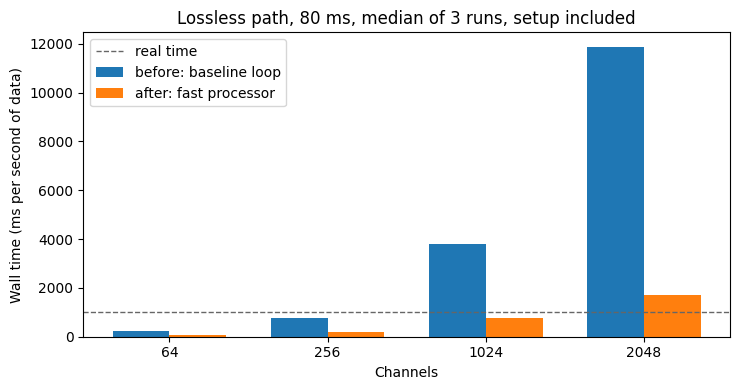

In [7]:
def median_ms_per_second(fn, neural_seconds, repeats=3):
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        quiet(fn)
        samples.append((time.perf_counter() - t0) / neural_seconds * 1000.0)
    return float(np.median(samples))


with Section("runtime including filter setup"):
    timing_ms = 80
    timing_rows = []
    for n_channels in (64, 256, 1024, 2048):
        data, params, thr, group_list = make_recording(n_channels, timing_ms, seed=1)
        neural_seconds = timing_ms / 1000.0
        before_cost = median_ms_per_second(
            lambda data=data, params=params, thr=thr: run_baseline(data, params, thr),
            neural_seconds,
        )
        after_cost = median_ms_per_second(
            lambda data=data, params=params, thr=thr, group_list=group_list: run_optimized(
                data, params, thr, group_list
            )[1],
            neural_seconds,
        )
        timing_rows.append((n_channels, "baseline", before_cost))
        timing_rows.append((n_channels, "fast", after_cost))

print(f"{'channels':>10} {'path':>22} {'ms wall / s data':>18}")
for n_channels, path, cost in timing_rows:
    print(f"{n_channels:10d} {path:>22} {cost:18.1f}")

labels = ["64", "256", "1024", "2048"]
before_bars = [row[2] for row in timing_rows if row[1] == "baseline"]
after_bars = [row[2] for row in timing_rows if row[1] == "fast"]
x = np.arange(len(labels))
width = 0.36
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x - width / 2, before_bars, width, label="before: baseline loop")
ax.bar(x + width / 2, after_bars, width, label="after: fast processor")
ax.axhline(1000, color="0.4", linestyle="--", linewidth=1, label="real time")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Channels")
ax.set_ylabel("Wall time (ms per second of data)")
ax.set_title("Lossless path, 80 ms, median of 3 runs, setup included")
ax.legend()
fig.tight_layout()
plt.show()


## Steady state, by stage

The processor is built once, warmed up, and then timed. Output arrays are created and filled before the timer starts, so the write column is the copy into the recording, not the first touch of a new array. The unit is ms wall per second of data.

Two rows per size: `scipy` is the original forward filter (`use_x86=False`), `avx512` is the compiled one. Only the forward filter differs between them; everything else is identical.

How to read the columns:

- **total** is the real clock time with no timers inside the loop. This is the number to quote.
- **reref, forward, reverse, features, write** come from a second pass that stops the clock between stages. Stopping the clock costs time, so these do not add up to the total. They show which stage is slowest and whether that ranking is stable.
- **largest on each repeat** lists the slowest stage on each of the three repeats. When all three agree, the ranking is stable.

Before the forward-filter change, the slowest stage at 1024 and 2048 was the forward filter. After it, the slowest stage is the reverse filter. That is why the reverse filter is the next thing to work on.


In [8]:
def stream_total(proc, raw, outputs, repeats):
    """Uninstrumented milliseconds of wall time per second of neural data."""
    n_ms = raw.shape[1] // SAMPLES_PER_MS
    spw = proc.samples_per_window
    reref, filt, sbp, spikes = outputs

    def once():
        for index in range(n_ms):
            proc._compute_window(raw[:, index * SAMPLES_PER_MS:(index + 1) * SAMPLES_PER_MS])
            out = index * spw
            reref[:, out:out + spw] = proc._reref_window
            filt[:, out:out + spw] = proc.filt_buffer
            sbp[:, index] = proc._sbp_win
            spikes[:, index] = proc._spikes_win

    once()
    samples = []
    neural = n_ms / 1000.0
    for _ in range(repeats):
        t0 = time.perf_counter()
        once()
        samples.append((time.perf_counter() - t0) / neural * 1000.0)
    return float(np.median(samples)), samples


def stream_split(proc, raw, outputs, repeats):
    """Instrumented stage times, milliseconds of wall time per second of data."""
    n_ms = raw.shape[1] // SAMPLES_PER_MS
    spw = proc.samples_per_window
    reref, filt, sbp, spikes = outputs
    keys = ("reref", "forward", "reverse", "features", "write")

    def once():
        acc = {key: 0.0 for key in keys}
        for index in range(n_ms):
            chunk = raw[:, index * SAMPLES_PER_MS:(index + 1) * SAMPLES_PER_MS]
            t0 = time.perf_counter()
            np.copyto(proc._raw_buf, chunk)
            proc._apply_reref()
            t1 = time.perf_counter()
            buf = proc.rev_buffer
            buf[:, :-spw] = buf[:, spw:]
            proc._forward_sos(proc._reref_window, buf[:, -spw:])
            t2 = time.perf_counter()
            proc._leading_nans = 0
            _apply_fir(buf, proc._rev_win, spw, proc.filt_buffer, proc._fir_band, 0)
            t3 = time.perf_counter()
            proc._features_all()
            t4 = time.perf_counter()
            out = index * spw
            reref[:, out:out + spw] = proc._reref_window
            filt[:, out:out + spw] = proc.filt_buffer
            sbp[:, index] = proc._sbp_win
            spikes[:, index] = proc._spikes_win
            t5 = time.perf_counter()
            acc["reref"] += t1 - t0
            acc["forward"] += t2 - t1
            acc["reverse"] += t3 - t2
            acc["features"] += t4 - t3
            acc["write"] += t5 - t4
        return acc

    once()
    rows = []
    neural = n_ms / 1000.0
    for _ in range(repeats):
        acc = once()
        rows.append({key: acc[key] / neural * 1000.0 for key in keys})
    median = {key: float(np.median([row[key] for row in rows])) for key in keys}
    largest_each = [max(row, key=row.get) for row in rows]
    return median, largest_each


def prepare(n_channels, n_ms, use_x86):
    data, params, thr, group_list = make_recording(n_channels, n_ms, seed=1)
    proc = quiet(lambda: OptimizedProcessor(
        n_channels=n_channels,
        reref_params=params,
        thresholds=thr,
        reref_groups=group_list,
        sample_rate=SAMPLE_RATE,
        use_gpu=False,
        decimate=False,
        per_array_threads=False,
        per_channel_threads=False,
        use_x86=use_x86,
    ))
    quiet(lambda: proc.process_recording(data[:, :SAMPLES_PER_MS * 20]))
    spw = proc.samples_per_window
    outputs = (
        np.zeros((n_channels, n_ms * spw), dtype=np.float32),
        np.zeros((n_channels, n_ms * spw), dtype=np.float32),
        np.zeros((n_channels, n_ms), dtype=np.float32),
        np.zeros((n_channels, n_ms), dtype=np.int16),
    )
    return proc, data, outputs


with Section("steady-state table"):
    STEADY = []
    for use_x86, impl in ((False, "scipy"), (True, "avx512")):
        for n_channels in (64, 256, 1024, 2048):
            proc, data, outputs = prepare(n_channels, 200, use_x86)
            total, samples = stream_total(proc, data, outputs, repeats=3)
            split, largest_each = stream_split(proc, data, outputs, repeats=3)
            STEADY.append(dict(
                channels=n_channels,
                impl=proc.forward_impl,
                total=total,
                samples=samples,
                split=split,
                largest_each=largest_each,
            ))
            proc.close()

print(cpu_label())
print(f"{'ch':>6} {'forward':>8} {'total':>8} {'reref':>8} {'forward':>8} {'reverse':>8} {'features':>8} {'write':>8}  largest on each repeat")
for row in STEADY:
    split = row["split"]
    print(
        f"{row['channels']:6d} {row['impl']:>8} {row['total']:8.1f} "
        f"{split['reref']:8.1f} {split['forward']:8.1f} {split['reverse']:8.1f} "
        f"{split['features']:8.1f} {split['write']:8.1f}  {row['largest_each']}"
    )

match_raw, match_params, match_thr, match_groups = make_recording(128, 80, seed=0)
scipy_out = quiet(lambda: run_optimized(
    match_raw, match_params, match_thr, match_groups, use_x86=False))[1]
avx_out = quiet(lambda: run_optimized(
    match_raw, match_params, match_thr, match_groups, use_x86=True))[1]
print(f"scipy vs avx512 max |filtered|: {np.nanmax(np.abs(scipy_out.filtered - avx_out.filtered)):.3e}")
print(f"spike mismatches: {int(np.sum(scipy_out.spikes != avx_out.spikes))}")


Intel(R) Xeon(R) Processor, 4 cores, AVX-512, KVM guest, x86_64
    ch  forward    total    reref  forward  reverse features    write  largest on each repeat
    64    scipy     91.5      7.5     47.1     12.3     20.3      3.9  ['forward', 'forward', 'forward']
   256    scipy    226.0     22.5    101.5     45.4     44.3     10.7  ['forward', 'forward', 'forward']
  1024    scipy    799.6    103.2    338.3    167.1    134.0     44.4  ['forward', 'forward', 'forward']
  2048    scipy   1497.8    232.3    626.5    306.1    243.4     89.1  ['forward', 'forward', 'forward']
    64   avx512     48.0      6.8      9.3     11.3     16.4      3.6  ['features', 'features', 'features']
   256   avx512    144.9     21.0     29.8     44.5     40.4     10.3  ['reverse', 'reverse', 'reverse']
  1024   avx512    579.2    100.9    133.7    162.2    132.6     44.3  ['reverse', 'reverse', 'reverse']
  2048   avx512   1180.8    230.5    270.7    352.0    236.7     90.8  ['reverse', 'reverse', 'reverse']

## Steady state on the real recording

Same measurement, on real samples. The 128-electrode row is the file as recorded. The 1024 and 2048 rows stack 8 and 16 copies of the 128 real electrodes side by side, with the fitted weights and thresholds repeated per copy, so every sample is a real waveform at those sizes. The per-electrode work does not depend on what the voltage looks like, so these rows should land near the synthetic rows; the spike count affects only the event list.


In [9]:
REAL_STEADY = []
if real is None:
    print("Real recording not found; skipped.")
else:
    def tile_real(copies, n_ms):
        n = real["raw"].shape[0]
        raw = np.tile(real["raw"][:, :n_ms * SAMPLES_PER_MS].astype(np.float64), (copies, 1))
        params = np.zeros((n * copies, n * copies))
        for c in range(copies):
            params[c * n:(c + 1) * n, c * n:(c + 1) * n] = real["params"]
        thr = np.tile(real["thr"], (copies, 1))
        groups = [[c * n + ch for ch in g] for c in range(copies) for g in real["groups"]]
        return raw, params, thr, groups

    with Section("real recording: steady state"):
        for use_x86, impl in ((False, "scipy"), (True, "avx512")):
            for copies in (1, 8, 16):
                n_ms = 200
                raw, params, thr, groups = tile_real(copies, n_ms + 20)
                n_channels = raw.shape[0]
                proc = quiet(lambda: OptimizedProcessor(
                    n_channels=n_channels, reref_params=params, thresholds=thr,
                    reref_groups=groups, sample_rate=SAMPLE_RATE, use_gpu=False,
                    decimate=False, per_array_threads=False,
                    per_channel_threads=False, use_x86=use_x86))
                quiet(lambda: proc.process_recording(raw[:, :SAMPLES_PER_MS * 20]))
                spw = proc.samples_per_window
                outputs = (
                    np.zeros((n_channels, n_ms * spw), dtype=np.float32),
                    np.zeros((n_channels, n_ms * spw), dtype=np.float32),
                    np.zeros((n_channels, n_ms), dtype=np.float32),
                    np.zeros((n_channels, n_ms), dtype=np.int16),
                )
                total, samples = stream_total(proc, raw[:, SAMPLES_PER_MS * 20:], outputs, repeats=3)
                REAL_STEADY.append((n_channels, proc.forward_impl, total))
                proc.close()
                del raw, params, outputs

    print(f"{'electrodes':>10} {'forward':>8} {'ms wall / s data':>18}  source")
    for n_channels, impl, total in REAL_STEADY:
        source = "real file" if n_channels == 128 else f"real file tiled x{n_channels // 128}"
        print(f"{n_channels:10d} {impl:>8} {total:18.1f}  {source}")


electrodes  forward   ms wall / s data  source
       128    scipy              130.9  real file
      1024    scipy              774.2  real file tiled x8
      2048    scipy             1545.3  real file tiled x16
       128   avx512               75.1  real file
      1024   avx512              585.2  real file tiled x8
      2048   avx512             1190.8  real file tiled x16


## Each approach on its own

The steady-state totals above are the combined effect. This section isolates each of the three working changes at 1024 electrodes, so the credit is explicit. For each stage it times the original method and the replacement on the same data, median of five runs of 200 windows, in ms wall per second of data.

- **Re-reference.** Original: rebuild the full 1024 × 1024 `(I − P)` and multiply, every millisecond. New: one 64 × 64 matrix per group, built once, applied as a batched multiply.
- **Forward filter.** Original: SciPy `sosfilt`. New: the same math compiled for AVX-512, eight electrodes per instruction, one thread.
- **Reverse filter.** Original: a Python `for` loop over electrodes calling `np.convolve`. New: one matrix multiply across all electrodes against a banded matrix of the filter taps.


In [10]:
def median_window_cost(fn, n_windows=200, repeats=5):
    """ms wall per second of data for a function that processes one window."""
    for _ in range(3):
        fn()
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for _ in range(n_windows):
            fn()
        samples.append((time.perf_counter() - t0) / (n_windows / 1000.0) * 1000.0)
    return float(np.median(samples))


with Section("each approach on its own"):
    ISO_CHANNELS = 1024
    iso_raw, iso_params, iso_thr, iso_groups = make_recording(ISO_CHANNELS, 40, seed=3)
    iso_proc = quiet(lambda: OptimizedProcessor(
        n_channels=ISO_CHANNELS, reref_params=iso_params, thresholds=iso_thr,
        reref_groups=iso_groups, use_gpu=False, use_x86=True,
        per_array_threads=False, per_channel_threads=False))
    scipy_proc = quiet(lambda: OptimizedProcessor(
        n_channels=ISO_CHANNELS, reref_params=iso_params, thresholds=iso_thr,
        reref_groups=iso_groups, use_gpu=False, use_x86=False,
        per_array_threads=False, per_channel_threads=False))
    for p in (iso_proc, scipy_proc):
        quiet(lambda p=p: p.process_recording(iso_raw[:, :SAMPLES_PER_MS * 8]))
    chunk = iso_raw[:, :SAMPLES_PER_MS]
    np.copyto(iso_proc._raw_buf, chunk)

    # Re-reference: original rebuilds the full matrix each call.
    reref_before = median_window_cost(lambda: rereference_data(chunk, iso_params))
    reref_after = median_window_cost(iso_proc._apply_reref)

    # Forward filter: SciPy versus the AVX-512 kernel, same input and destination.
    fwd_dest = iso_proc.rev_buffer[:, -SAMPLES_PER_MS:]
    forward_before = median_window_cost(
        lambda: scipy_proc._forward_sos(scipy_proc._reref_window, fwd_dest))
    forward_after = median_window_cost(
        lambda: iso_proc._forward_sos(iso_proc._reref_window, fwd_dest))

    # Reverse filter: Python convolve loop versus one multiply, same buffer.
    rev_buffer = iso_proc.rev_buffer
    rev_win = iso_proc._rev_win
    filt_out = np.empty_like(iso_proc.filt_buffer)

    def convolve_loop():
        for channel in range(ISO_CHANNELS):
            filt_out[channel, ::-1] = np.convolve(rev_buffer[channel, ::-1], rev_win, "valid")

    reverse_before = median_window_cost(convolve_loop)
    reverse_after = median_window_cost(
        lambda: _apply_fir(rev_buffer, rev_win, SAMPLES_PER_MS, filt_out,
                           iso_proc._fir_band, 0))

    APPROACHES = [
        ("Re-reference", "rebuild full matrix every ms", "one 64x64 block per group, built once", reref_before, reref_after),
        ("Forward filter", "SciPy sosfilt", "AVX-512, 8 electrodes per instruction", forward_before, forward_after),
        ("Reverse filter", "Python loop, np.convolve per electrode", "one matrix multiply", reverse_before, reverse_after),
    ]
    iso_proc.close()
    scipy_proc.close()

print(f"{ISO_CHANNELS} electrodes, ms wall per second of data, median of 5 runs of 200 windows")
print(f"{'stage':<16} {'before':>8} {'after':>8} {'saved':>8} {'speedup':>8}  original -> new")
for stage, old, new, t_before, t_after in APPROACHES:
    print(f"{stage:<16} {t_before:8.1f} {t_after:8.1f} {t_before - t_after:8.1f} {t_before / t_after:7.1f}x  {old} -> {new}")


1024 electrodes, ms wall per second of data, median of 5 runs of 200 windows
stage              before    after    saved  speedup  original -> new
Re-reference       1298.5     57.4   1241.1    22.6x  rebuild full matrix every ms -> one 64x64 block per group, built once
Forward filter      226.1     59.5    166.5     3.8x  SciPy sosfilt -> AVX-512, 8 electrodes per instruction
Reverse filter     1962.8    160.4   1802.4    12.2x  Python loop, np.convolve per electrode -> one matrix multiply


## Sparse spikes

Most milliseconds have no spike on most electrodes. The full grid stores a number for every electrode and every millisecond anyway. The event list stores only `(electrode, millisecond)` for bins that fired. The compressed (CSR) matrix stores the same nonzeros plus a row index. This is a storage result, not a speed result: building the list is extra work, so the full grid stays the default when the next step wants it in memory.


In [11]:
with Section("sparse spikes"):
    dense_bytes = after.spikes.nbytes
    event_bytes = after.spike_events.nbytes
    sparse = after.spikes_sparse
    csr_bytes = sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes
    n_bins = after.spikes.size
    n_spikes = int(after.spikes.sum())
print(f"bins:                 {n_bins}")
print(f"spikes:               {n_spikes} ({100.0 * n_spikes / n_bins:.3f}% of bins)")
print(f"dense int16 raster:   {dense_bytes:,} bytes")
print(f"event list:           {event_bytes:,} bytes  ({dense_bytes / max(event_bytes, 1):.1f}x smaller)")
print(f"CSR matrix:           {csr_bytes:,} bytes  ({dense_bytes / max(csr_bytes, 1):.1f}x smaller)")
print(f"event rows match nnz: {after.spike_events.shape[0] == sparse.nnz}")


bins:                 25600
spikes:               19 (0.074% of bins)
dense int16 raster:   51,200 bytes
event list:           152 bytes  (336.8x smaller)
CSR matrix:           630 bytes  (81.3x smaller)
event rows match nnz: True


## Decimation (the lossy option, off by default)

Dropping every other sample halves the work of every later stage. Done naively, any signal above 7.5 kHz folds down into the spike band. So the processor first low-passes at 6 kHz with an order-8 Butterworth, then keeps every other sample. A 1 kHz tone (inside the spike band) should pass unchanged; a 12 kHz tone should be removed; the same 12 kHz tone with a bare skip should survive, which is the problem being avoided.

This changes the waveforms, so it does not match the original loop and stays off unless `decimate=True`. It is the fallback if 2048 electrodes must reach real time on this CPU.


samples in / out:          6000 / 3000 (2x)
1 kHz after decimation:    -0.0 dB vs raw
12 kHz after decimation:   -100.3 dB vs raw
12 kHz naive skip:         +0.0 dB vs raw


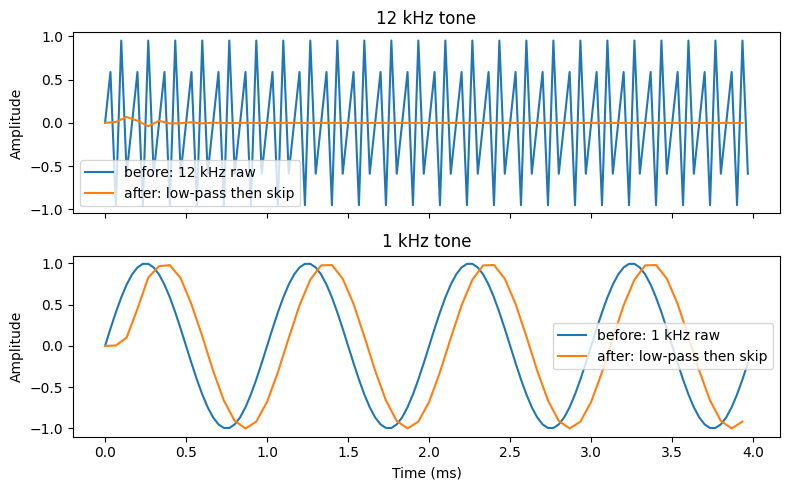

processor input samples/ms:  30
processor output samples/ms: 15
decimated recording:         True, process rate 15000 Hz


In [12]:
with Section("decimation"):
    duration_s = 0.2
    n_samples = int(duration_s * SAMPLE_RATE)
    t = np.arange(n_samples) / SAMPLE_RATE
    tone_1k = np.sin(2 * np.pi * 1000 * t)
    tone_12k = np.sin(2 * np.pi * 12000 * t)
    skip = 400

    def rms(values):
        return float(np.sqrt(np.mean(np.square(values))))

    decimated_1k = AntiAliasDecimator(1, SAMPLE_RATE).process(tone_1k[None, :])[0]
    decimated_12k = AntiAliasDecimator(1, SAMPLE_RATE).process(tone_12k[None, :])[0]
    naive_12k = tone_12k[::2]

    def decibel(out, reference):
        return 20.0 * np.log10(rms(out) / rms(reference))

    lossy_raw, lossy_params, lossy_thr, lossy_groups = make_recording(64, 100, seed=2)
    lossy = quiet(lambda: run_optimized(
        lossy_raw, lossy_params, lossy_thr, lossy_groups, decimate=True
    )[1])

print(f"samples in / out:          {n_samples} / {decimated_1k.size} ({n_samples / decimated_1k.size:.0f}x)")
print(f"1 kHz after decimation:    {decibel(decimated_1k[skip:], tone_1k[skip * 2:]):+.1f} dB vs raw")
print(f"12 kHz after decimation:   {decibel(decimated_12k[skip:], tone_12k[skip * 2:]):+.1f} dB vs raw")
print(f"12 kHz naive skip:         {decibel(naive_12k[skip:], tone_12k[skip * 2:]):+.1f} dB vs raw")

show_s = 0.004
show_n = int(show_s * SAMPLE_RATE)
time_ms = np.arange(show_n) / SAMPLE_RATE * 1000
time_ms_out = np.arange(show_n // 2) / (SAMPLE_RATE / 2) * 1000
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(time_ms, tone_12k[:show_n], label="before: 12 kHz raw")
axes[0].plot(time_ms_out, decimated_12k[:show_n // 2], label="after: low-pass then skip")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("12 kHz tone")
axes[0].legend()
axes[1].plot(time_ms, tone_1k[:show_n], label="before: 1 kHz raw")
axes[1].plot(time_ms_out, decimated_1k[:show_n // 2], label="after: low-pass then skip")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("1 kHz tone")
axes[1].legend()
fig.tight_layout()
plt.show()

print(f"processor input samples/ms:  {SAMPLES_PER_MS}")
print(f"processor output samples/ms: {lossy.filtered.shape[1] // lossy.spikes.shape[1]}")
print(f"decimated recording:         {lossy.decimated}, process rate {lossy.process_rate:.0f} Hz")


## GPU

`use_gpu="auto"` runs the filter in PyTorch when a device is visible. An Apple GPU or a GPU that shares system memory is preferred, so 2048 electrodes do not have to be copied across a bus every millisecond. This cell reports what this computer has. The GPU path matches the CPU path in the tests, but it has never been timed, because no machine used so far has a GPU.


In [13]:
with Section("gpu check"):
    device, kind = select_gpu_device()
if device is None:
    print("No CUDA or MPS device. Filtering stays on the CPU.")
else:
    print(f"GPU device: {device}, memory: {kind}")


No CUDA or MPS device. Filtering stays on the CPU.


## Attempts that did not help

Each row is an idea that was implemented, measured, and removed. Next to it is the reference: the same work without that idea, on the same data and size. Times are the median of three runs in ms wall per second of data. **Latency added** is the row minus its reference. A positive number means the idea made the pipeline slower by that much.

Why each one failed:

- **Thread pool around each millisecond.** Submitting work to a pool and waiting for it costs tens of microseconds per task. A millisecond of work for 64 electrodes is smaller than that overhead, so threads lose before they start. Python's interpreter lock also keeps the NumPy loop from running in parallel.
- **One Python thread per electrode.** Same problem, multiplied by the number of electrodes.
- **Fortran-order output buffer.** The idea was that each window's write would be one contiguous block. It is, but the recording then has to be copied back to the normal layout at the end, and that copy walks the whole array with a bad stride. The copy costs at least what the contiguous writes saved: across runs this row has come out between even and about 20% slower than the plain C-order recording. Nothing gained for extra code.
- **OpenMP (multi-threaded) forward filter.** The compiled filter was faster on its own. But the reverse filter is a BLAS multiply, and BLAS keeps its own thread pool on the same four cores. With both pools active in one process, each millisecond stalls while the two fight for cores, and the multiply slows from well under a millisecond to several. The single-thread AVX-512 version keeps the speedup without the fight.

The OpenMP row is measured last on purpose: once that thread pool exists, it distorts every BLAS measurement that follows it in the same process.


In [14]:
def median_call(fn, neural_seconds, repeats=3):
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        samples.append((time.perf_counter() - t0) / neural_seconds * 1000.0)
    return float(np.median(samples))


def serial_python_convolve(data, params, workers=1):
    """Baseline reverse FIR. workers=1 is serial. workers>1 pools channel blocks each millisecond."""
    import scipy.signal
    n_channels = data.shape[0]
    n_windows = data.shape[1] // SAMPLES_PER_MS
    lag = int(round(0.004 * SAMPLE_RATE))
    _, sos, zi, rev_win, _ = build_filter(
        n_channels=n_channels, but_low=250, but_high=5000, causal=False,
        acausal_filter_type="fir", acausal_filter_lag=lag, fs=SAMPLE_RATE,
    )
    rev_buffer = np.full((n_channels, lag + SAMPLES_PER_MS), np.nan, dtype=np.float32)
    filt_buffer = np.zeros((n_channels, SAMPLES_PER_MS), dtype=np.float32)
    edges = np.linspace(0, n_channels, max(workers, 1) + 1, dtype=int)
    blocks = [slice(int(a), int(b)) for a, b in zip(edges[:-1], edges[1:]) if b > a]

    def convolve_block(sl):
        for channel in range(sl.start, sl.stop):
            filt_buffer[channel, ::-1] = np.convolve(
                rev_buffer[channel, ::-1], rev_win, "valid")

    def one_window(index):
        start = index * SAMPLES_PER_MS
        chunk = rereference_data(data[:, start:start + SAMPLES_PER_MS], params)
        rev_buffer[:, :-SAMPLES_PER_MS] = rev_buffer[:, SAMPLES_PER_MS:]
        forward, zi_next = scipy.signal.sosfilt(sos, chunk, axis=1, zi=zi)
        rev_buffer[:, -SAMPLES_PER_MS:] = forward
        zi[:, :] = zi_next
        if workers <= 1:
            convolve_block(slice(0, n_channels))
        else:
            list(pool.map(convolve_block, blocks))

    if workers <= 1:
        for index in range(n_windows):
            one_window(index)
        return
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for index in range(n_windows):
            one_window(index)


def output_layout(n_channels, n_ms, order):
    """Stream into a C-order recording, or into a Fortran buffer that is copied back at the end."""
    data, params, thr, group_list = make_recording(n_channels, n_ms, seed=4)
    proc = quiet(lambda: OptimizedProcessor(
        n_channels=n_channels, reref_params=params, thresholds=thr,
        reref_groups=group_list, use_gpu=False, use_x86=True,
        per_array_threads=False, per_channel_threads=False,
    ))
    quiet(lambda: proc.process_recording(data[:, :SAMPLES_PER_MS * 8]))
    spw = proc.samples_per_window
    hold = np.empty((n_channels, n_ms * spw), dtype=np.float32, order=order)
    for index in range(n_ms):
        proc._compute_window(data[:, index * SAMPLES_PER_MS:(index + 1) * SAMPLES_PER_MS])
        out = index * spw
        hold[:, out:out + spw] = proc.filt_buffer
    if order == "F":
        np.ascontiguousarray(hold)
    proc.close()


def forward_then_multiply(n_channels, n_windows, parallel):
    """Forward filter plus the reverse-filter multiply. parallel=True uses an OpenMP loop."""
    import scipy.signal
    from numba import njit, prange

    sos = np.ascontiguousarray(scipy.signal.butter(
        4, [250.0, 5000.0], btype="bandpass", output="sos", fs=float(SAMPLE_RATE)))
    norm = np.empty((sos.shape[0], 5))
    for section in range(sos.shape[0]):
        scale = 1.0 / sos[section, 3]
        norm[section] = [
            sos[section, 0] * scale, sos[section, 1] * scale, sos[section, 2] * scale,
            sos[section, 4] * scale, sos[section, 5] * scale,
        ]
    norm = np.ascontiguousarray(norm)
    rng = np.random.default_rng(0)
    data = rng.normal(size=(n_channels, SAMPLES_PER_MS))
    xt = np.ascontiguousarray(data.T)
    z1 = np.zeros((norm.shape[0], n_channels))
    z2 = np.zeros_like(z1)
    buf = rng.normal(size=(n_channels, 150))
    band = rng.normal(size=(150, SAMPLES_PER_MS))

    if parallel:
        @njit(nogil=True, parallel=True, cache=False)
        def step(norm, xt, z1, z2):
            n_ch = xt.shape[1]
            tile = 256
            n_tiles = (n_ch + tile - 1) // tile
            for tile_index in prange(n_tiles):
                c0 = tile_index * tile
                c1 = min(n_ch, c0 + tile)
                for section in range(norm.shape[0]):
                    b0, b1, b2, a1, a2 = norm[section]
                    for sample in range(xt.shape[0]):
                        for channel in range(c0, c1):
                            xn = xt[sample, channel]
                            yn = b0 * xn + z1[section, channel]
                            z1[section, channel] = b1 * xn - a1 * yn + z2[section, channel]
                            z2[section, channel] = b2 * xn - a2 * yn
                            xt[sample, channel] = yn
    else:
        step = None

    def run_serial():
        # Reuse the shipped single-thread AVX-512 kernel on a private filter.
        from x86_forward import try_create_forward
        zi = np.zeros((sos.shape[0], n_channels, 2))
        forward = try_create_forward(sos, zi, SAMPLES_PER_MS)
        dest = np.empty((n_channels, SAMPLES_PER_MS), dtype=np.float64)
        for _ in range(n_windows):
            forward.apply(data, dest)
            buf @ band

    def run_parallel():
        step(norm, xt, z1, z2)  # compile
        for _ in range(n_windows):
            xt[:, :] = data.T
            step(norm, xt, z1, z2)
            buf @ band

    if parallel:
        run_parallel()
    else:
        run_serial()


with Section("rejected optimizations"):
    DEGRADED = []
    data64, params64, _, _ = make_recording(64, 40, seed=4)
    serial_64 = median_call(lambda: quiet(lambda: serial_python_convolve(data64, params64, 1)), 0.040)
    pooled_64 = median_call(lambda: quiet(lambda: serial_python_convolve(data64, params64, 4)), 0.040)
    per_channel = median_call(lambda: quiet(lambda: serial_python_convolve(data64, params64, 64)), 0.040)
    DEGRADED.append(("serial Python convolution", 64, serial_64, "reference"))
    DEGRADED.append(("thread pool around each millisecond", 64, pooled_64, "4 workers, same convolution"))
    DEGRADED.append(("one Python thread per channel", 64, per_channel, "64 workers, same convolution"))

    c_order = median_call(lambda: output_layout(1024, 80, "C"), 0.080)
    f_order = median_call(lambda: output_layout(1024, 80, "F"), 0.080)
    DEGRADED.append(("C-order recording, strided window writes", 1024, c_order, "reference"))
    DEGRADED.append(("Fortran-order buffer, then a full copy back", 1024, f_order, "same stream, different layout"))

    serial_both = median_call(lambda: forward_then_multiply(1024, 80, False), 0.080)
    parallel_both = median_call(lambda: forward_then_multiply(1024, 80, True), 0.080)
    DEGRADED.append(("AVX-512 forward filter, then the multiply", 1024, serial_both, "reference"))
    DEGRADED.append(("OpenMP forward filter, then the multiply", 1024, parallel_both, "same multiply, parallel forward filter"))

print(f"{'attempt':<48} {'ch':>6} {'ms/s':>8}  note")
for name, n_channels, cost, note in DEGRADED:
    print(f"{name:<48} {n_channels:6d} {cost:8.1f}  {note}")


attempt                                              ch     ms/s  note
serial Python convolution                            64    210.9  reference
thread pool around each millisecond                  64    458.3  4 workers, same convolution
one Python thread per channel                        64   1671.6  64 workers, same convolution
C-order recording, strided window writes           1024   1086.0  reference
Fortran-order buffer, then a full copy back        1024   1283.4  same stream, different layout
AVX-512 forward filter, then the multiply          1024    154.9  reference
OpenMP forward filter, then the multiply           1024  13952.9  same multiply, parallel forward filter


## Results at a glance

Everything above, in two tables. The first lists what was changed and what each change saved. The second lists what was tried and removed, how much latency it added, and why. Below the tables: the total notebook runtime, the runtime of each timed cell, and a few sentences that say what the numbers mean.


In [15]:
with Section("summary"):
    pass

by_impl = {}
for row in STEADY:
    by_impl.setdefault(row["impl"], {})[row["channels"]] = row

print(cpu_label())
print()
print("=" * 78)
print("WHAT WORKED  (same output as the original loop)")
print("=" * 78)
print(f"{'change':<16} {'before':>8} {'after':>8} {'saved':>8}  how it works")
for stage, old, new, t_before, t_after in APPROACHES:
    print(f"{stage:<16} {t_before:8.1f} {t_after:8.1f} {t_before - t_after:8.1f}  {old} -> {new}")
print(f"({ISO_CHANNELS} electrodes, each stage timed alone, ms wall per second of data)")
print()
print("Combined effect, steady state, processor already built:")
print(f"{'electrodes':>10} {'original loop*':>15} {'two changes':>12} {'all three':>10}  real time?")
for n_channels in (64, 256, 1024, 2048):
    original = next(c for n, p, c in timing_rows if n == n_channels and p == "baseline")
    two = by_impl["scipy"][n_channels]["total"]
    three = by_impl["avx512"][n_channels]["total"]
    verdict = "yes" if three < 1000 else "no"
    print(f"{n_channels:10d} {original:15.0f} {two:12.0f} {three:10.0f}  {verdict}")
print("* original loop measured with setup included; the two right columns are steady state.")
print("  'two changes' = block re-reference + reverse multiply (SciPy forward filter).")
print("  'all three'  = those two + the AVX-512 forward filter.")
if real is not None:
    print()
    print(f"Real recording, {REAL_SECONDS} s of NSP1_aligned.ns6, 128 electrodes:")
    print(f"  spikes original / fast: {int(real_before[1].sum())} / {int(real_after.spikes.sum())}, "
          f"mismatched bins {int(np.sum(real_after.spikes != real_before[1]))}, "
          f"max filtered difference {np.nanmax(np.abs(real_after.filtered - real_before[0])):.1e}")
    for n_channels, impl, total in REAL_STEADY:
        if impl == "avx512":
            source = "as recorded" if n_channels == 128 else f"tiled x{n_channels // 128}"
            print(f"  {n_channels:5d} electrodes ({source}): {total:.0f} ms wall per second of data")

print()
print("=" * 78)
print("WHAT DID NOT WORK  (tried, measured, removed)")
print("=" * 78)
WHY = {
    "thread pool around each millisecond": "pool overhead per task exceeds 1 ms of work; interpreter lock",
    "one Python thread per channel": "same overhead, once per electrode",
    "Fortran-order buffer, then a full copy back": "final copy back costs what the contiguous writes saved",
    "OpenMP forward filter, then the multiply": "two thread pools fight over 4 cores; BLAS multiply stalls",
}
rows = []
for name, n_channels, cost, note in DEGRADED:
    if note.startswith("reference"):
        continue
    if "thread" in name:
        ref = next(c for n, ch, c, nt in DEGRADED if nt.startswith("reference") and ch == n_channels and "convolution" in n)
    elif "Fortran" in name:
        ref = next(c for n, ch, c, nt in DEGRADED if nt.startswith("reference") and "C-order" in n)
    else:
        ref = next(c for n, ch, c, nt in DEGRADED if nt.startswith("reference") and "AVX-512 forward" in n)
    rows.append((name, n_channels, ref, cost, cost - ref, WHY.get(name, "")))
print(f"{'attempt':<44} {'ch':>5} {'without':>8} {'with':>8} {'added':>8}  why")
for name, n_channels, ref, cost, added, why in rows:
    print(f"{name:<44} {n_channels:5d} {ref:8.0f} {cost:8.0f} {added:+8.0f}  {why}")
print("(ms wall per second of data; 'added' is with minus without)")

print()
print("=" * 78)
print("NOT MEASURED HERE")
print("=" * 78)
print("GPU path: implemented and tested against the CPU path, never timed (no GPU on this machine).")
print("15 kHz option: implemented, correct in the tone test, off by default because it changes the waveforms.")

print()
print("=" * 78)
print("NOTEBOOK RUNTIME")
print("=" * 78)
total_s = time.perf_counter() - NOTEBOOK_T0
print(f"total: {total_s:.1f} s")
for name, seconds in SECTION_TIMES:
    print(f"  {name:<40} {seconds:8.2f} s")

print()
avx_1024 = by_impl["avx512"][1024]
avx_2048 = by_impl["avx512"][2048]
scipy_1024 = by_impl["scipy"][1024]
print("IN WORDS")
print(f"- Before the forward-filter change, the slowest stage at 1024 and 2048 electrodes was "
      f"'{max(set(scipy_1024['largest_each']), key=scipy_1024['largest_each'].count)}' on every repeat.")
print(f"- After it, the slowest stage is '{max(set(avx_1024['largest_each']), key=avx_1024['largest_each'].count)}'. "
      f"That is the next stage to change.")
if avx_1024["total"] < 1000:
    print(f"- 1024 electrodes: {avx_1024['total']:.0f} ms per second of data. Real time.")
else:
    print(f"- 1024 electrodes: {avx_1024['total']:.0f} ms per second of data. Over the line.")
print(f"- 2048 electrodes: {avx_2048['total']:.0f} ms per second of data. "
      f"{'Real time.' if avx_2048['total'] < 1000 else 'Over the line; about ' + format(avx_2048['total'] / 1000, '.1f') + 'x too slow.'}")
print("- Every lossless change was checked against the original loop on synthetic and real data, difference 0.")


Intel(R) Xeon(R) Processor, 4 cores, AVX-512, KVM guest, x86_64

WHAT WORKED  (same output as the original loop)
change             before    after    saved  how it works
Re-reference       1298.5     57.4   1241.1  rebuild full matrix every ms -> one 64x64 block per group, built once
Forward filter      226.1     59.5    166.5  SciPy sosfilt -> AVX-512, 8 electrodes per instruction
Reverse filter     1962.8    160.4   1802.4  Python loop, np.convolve per electrode -> one matrix multiply
(1024 electrodes, each stage timed alone, ms wall per second of data)

Combined effect, steady state, processor already built:
electrodes  original loop*  two changes  all three  real time?
        64             218           91         48  yes
       256             767          226        145  yes
      1024            3787          800        579  yes
      2048           11873         1498       1181  no
* original loop measured with setup included; the two right columns are steady state.
  'two c

## Earlier table, for comparison

The first comparison, from September. That run built the filter on every repetition and did not yet compile the forward filter. Median of three 80 ms runs, ms wall per second of data:

| electrodes | original loop | after the first two changes |
| --- | ---: | ---: |
| 64 | 206 | 117 |
| 256 | 786 | 307 |
| 1024 | 4088 | 1085 |
| 2048 | 14076 | 2253 |

At that point 64 and 256 were under the real-time line with setup included, 1024 was just over, and 2048 was about twice real time. The steady-state tables in this notebook supersede these numbers.
